'''TASK 3·Fraud Detection
Objective: Build a machine learning pipeline to detect fraudulent financial transactions from a heavily imbalanced dataset, addressing class imbalance as a core challenge.'''

'''1.Load dataset and analyse class imbalance: what percentage of transactions are fraudulent?'''

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder

In [3]:
df=pd.read_csv("C:/Users/Ayush Singh/OIBSIB/L2-CreditFraud.csv")
print(df)
total=len(df)
print(df.columns)
fraud_count=df['is_fraud'].sum()
fraud_pct= (fraud_count/total)*100
print(f"Total Transactions: {total:,}")
print(f"Fraudulent Transactions: {fraud_count:,}")
print(f"Fraud Percentage: {fraud_pct:.4f}%")
print(f"Ratio: 1 Fraud in every {total/fraud_count:.0f} transactions")
print(df['is_fraud'].value_counts()) 

      transaction_id  amount  transaction_hour merchant_category  \
0                  1   84.47                22       Electronics   
1                  2  541.82                 3            Travel   
2                  3  237.01                17           Grocery   
3                  4  164.33                 4           Grocery   
4                  5   30.53                15              Food   
...              ...     ...               ...               ...   
9995            9996  350.91                22              Food   
9996            9997  410.04                 5          Clothing   
9997            9998  527.75                21       Electronics   
9998            9999   91.20                 2       Electronics   
9999           10000   44.06                 2          Clothing   

      foreign_transaction  location_mismatch  device_trust_score  \
0                       0                  0                  66   
1                       1                  0   

'''2.EDA: distribution of transaction amounts for fraud vs. non-fraud; time-of-day analysis'''

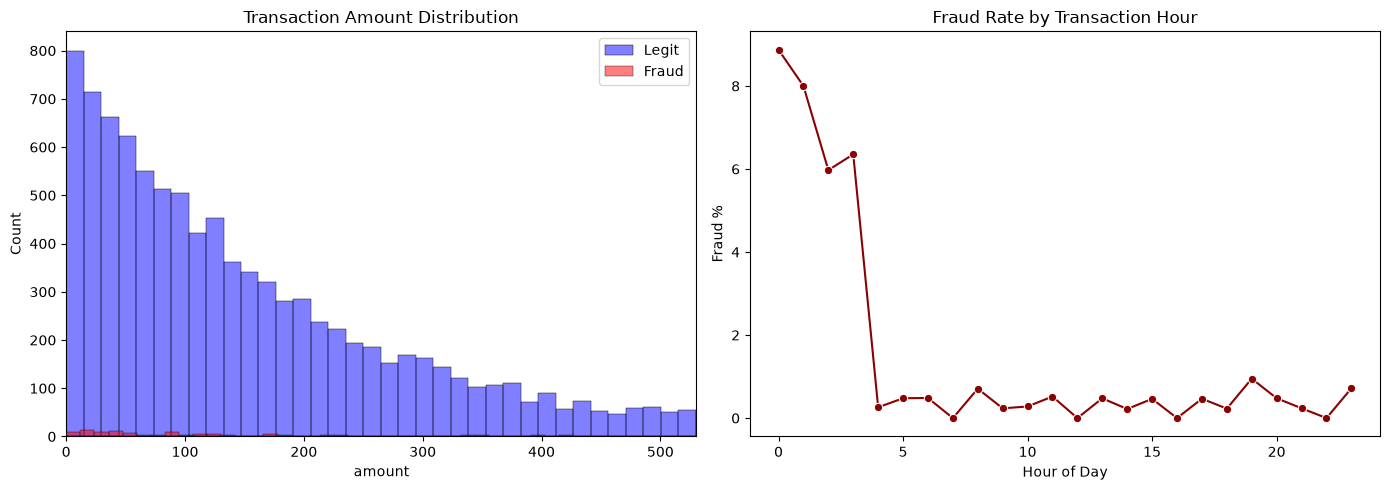

In [4]:
plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
sns.histplot(data=df[df['is_fraud']==0],x='amount',bins=100,label='Legit',color='blue',alpha=0.5)
sns.histplot(data=df[df['is_fraud']==1],x='amount',bins=100,label='Fraud',color='red',alpha=0.5)
plt.title('Transaction Amount Distribution')
plt.legend()
plt.xlim(0, df['amount'].quantile(0.95)) # Focuses on 95% of data
plt.subplot(1,2,2) #by hr
hourly_fraud= df.groupby('transaction_hour')['is_fraud'].mean()*100
sns.lineplot(x=hourly_fraud.index,y=hourly_fraud.values,marker='o',color='darkred')
plt.title('Fraud Rate by Transaction Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Fraud %')
plt.tight_layout()
plt.show()

'''3.Discuss why standard accuracy is a misleading metric for imbalanced fraud datasets (explain in a markdown cell)'''

With fraud rates often below 1%, a model that predicts "No Fraud" for every transaction set achieving >99% accuracy but it catches zero fraud.
In your dataset, if fraud is ~0.2%, accuracy is useless.
So, we must optimize for Recall for catching fraud in dataset and Precision aiming to avoiding false alarms, summarized by the F1-Score and AUC-ROC.

'''4.Apply a class imbalance handling technique: SMOTE oversampling, undersampling, or class_weight='balanced''''

In [5]:
le=LabelEncoder() #i used 'merchant_category' column as class_weight isnt in my used dataset
df['merchant_category_encoded']= le.fit_transform(df['merchant_category'].astype(str))
feature_cols=['amount','transaction_hour','merchant_category_encoded','foreign_transaction','location_mismatch','device_trust_score','velocity_last_24h','cardholder_age']
X=df[feature_cols]
y=df['is_fraud']
X_train,X_test,y_train,y_test= train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
smote= SMOTE(random_state=42) #applying smote
X_train_res,y_train_res= smote.fit_resample(X_train,y_train)
print(f"Original Train Fraud %: {y_train.mean()*100:.2f}%")
print(f"Resampled Train Fraud %: {y_train_res.mean()*100:.2f}%")   

Original Train Fraud %: 1.51%
Resampled Train Fraud %: 50.00%


'''5.Train/test split atleast 2 models (ensure fraud cases appear in both splits using stratification)'''

In [6]:
lr= LogisticRegression(max_iter=1000,random_state=42) #model 1: Logistic Regression
lr.fit(X_train_res,y_train_res)
rf= RandomForestClassifier(n_estimators=100,random_state=42,n_jobs=-1) #model 2: Random Forest
rf.fit(X_train_res,y_train_res)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

'''6.Evaluate using: Precision, Recall, F1-Score, and AUC-ROC curve (not just accuracy)'''

In [7]:
def evaluate(name, model):
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    print(f"{name}")
    print(classification_report(y_test, pred))
    print(f"AUC-ROC: {roc_auc_score(y_test, prob):.4f}\n")
evaluate("Logistic Regression", lr)
evaluate("Random Forest", rf)   

Logistic Regression
              precision    recall  f1-score   support

           0       1.00      0.88      0.94      1970
           1       0.12      1.00      0.21        30

    accuracy                           0.89      2000
   macro avg       0.56      0.94      0.57      2000
weighted avg       0.99      0.89      0.93      2000

AUC-ROC: 0.9905

Random Forest
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1970
           1       0.36      0.87      0.50        30

    accuracy                           0.97      2000
   macro avg       0.68      0.92      0.75      2000
weighted avg       0.99      0.97      0.98      2000

AUC-ROC: 0.9897



'''7.Explain which metric matters most for fraud detection and why'''

'''8.Feature importance or coefficient analysis'''

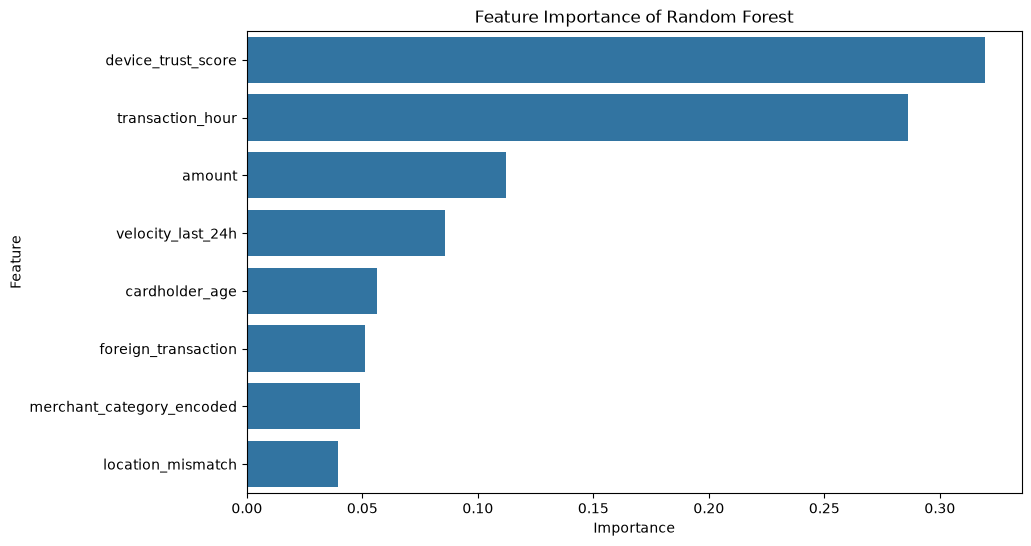


Top Coefficients of Logistic Regression:
               Feature  Coefficient
4    location_mismatch     3.008026
3  foreign_transaction     2.424045
6    velocity_last_24h     0.830820
1     transaction_hour    -0.285670
5   device_trust_score    -0.120121


In [8]:
fi= pd.DataFrame({'Feature': feature_cols,'Importance': rf.feature_importances_})
fi= fi.sort_values(by='Importance',ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(data=fi,x='Importance',y='Feature')
plt.title('Feature Importance of Random Forest')
plt.show()
coeffs= pd.DataFrame({'Feature': feature_cols,'Coefficient': lr.coef_[0]})
coeffs= coeffs.sort_values(by='Coefficient',key=abs,ascending=False)
print("\nTop Coefficients of Logistic Regression:")
print(coeffs.head())   

'''9. Discuss scalability: how would this model handle 1 million transactions per hour?'''